# CH 6 - Data-Mining Bias - Two Components of Observed Performance

## Objectif pédagogique

Ce notebook explique le cœur du **data-mining bias** : pourquoi la meilleure règle trouvée en backtest est souvent la plus dangereuse à croire aveuglément.

L’idée centrale est simple :

> La **performance observée** n’est pas égale au talent réel de la règle.  
> Elle est un mélange entre **pouvoir prédictif durable** et **hasard non récurrent**.

Dans le langage EBTA :

$$
P_{obs} = P_{pred} + H
$$

où :

| Symbole | Signification | Nature |
|---|---|---|
| $P_{obs}$ | **Performance observée** en backtest | Mesurée sur le passé |
| $P_{pred}$ | **Pouvoir prédictif réel** | Composante durable |
| $H$ | **Hasard** | Composante non récurrente |

> L’erreur du trader consiste à prendre $P_{obs}$ pour $P_{pred}$.


## 1. Le problème : le backtest mélange talent et chance

Quand une règle affiche une belle performance historique, cette performance peut venir de deux sources :

- une vraie propriété exploitable du marché ;
- une coïncidence favorable entre les signaux et le bruit du marché.

Le problème n’est pas seulement que le hasard existe.

Le vrai danger apparaît quand on teste beaucoup de règles puis qu’on sélectionne uniquement la meilleure.

> Plus on cherche, plus on augmente la probabilité de trouver une règle chanceuse.

C’est le mécanisme du **biais de minage de données**.


## 2. La décomposition fondamentale

La performance observée peut être formulée ainsi :

$$
\text{Performance Observée}
=
\text{Pouvoir Prédictif}
+
\text{Hasard}
$$

ou, en notation compacte :

$$
P_{obs} = P_{pred} + H
$$

La composante $P_{pred}$ représente ce qui peut raisonnablement se répéter.

La composante $H$ représente le bruit : chance ou malchance. Elle peut être très forte dans un échantillon fini, mais elle n’est pas une promesse pour le futur.

> Le hasard peut gonfler un backtest, mais il ne signe aucun contrat avec ton futur.


## 3. Exemple intuitif : une seule règle

Imaginons une règle qui possède réellement une espérance de gain de $5\%$.

Sur un backtest donné, elle peut afficher $18\%$ simplement parce que le hasard a ajouté $13\%$.

$$
18\% = 5\% + 13\%
$$

Mais en trading réel, la composante $13\%$ ne doit pas être considérée comme durable.

L’attente raisonnable n’est donc pas $18\%$, mais plutôt quelque chose proche de $5\%$, avant frais, slippage et changement de régime.

> Le backtest te montre ce qui s’est passé.  
> L’inférence statistique cherche à estimer ce qui est durable.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paramètres reproductibles
rng = np.random.default_rng(42)

true_predictive_power = 0.05   # 5% de mérite réel
random_component = 0.13        # +13% de chance sur cet échantillon

observed_performance = true_predictive_power + random_component

pd.DataFrame({
    "Composante": ["Pouvoir prédictif réel", "Hasard favorable", "Performance observée"],
    "Valeur": [true_predictive_power, random_component, observed_performance],
    "Valeur %": [f"{true_predictive_power:.1%}", f"{random_component:.1%}", f"{observed_performance:.1%}"]
})


,Composante,Valeur,Valeur %
0,Pouvoir prédictif réel,0.05,5.0%
1,Hasard favorable,0.13,13.0%
2,Performance observée,0.18,18.0%


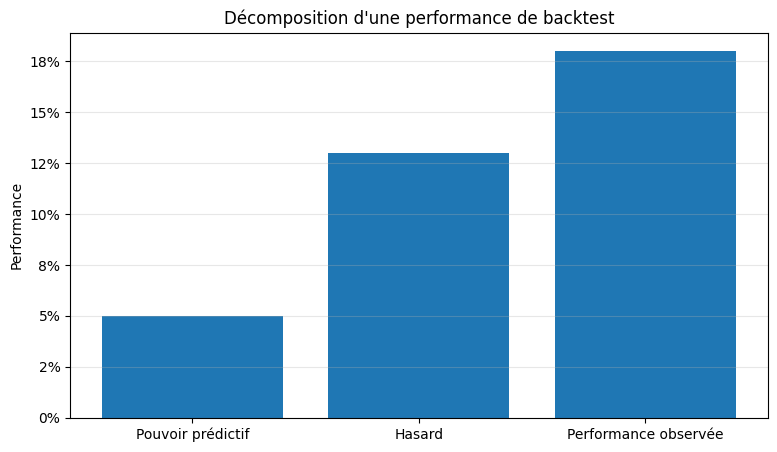

In [2]:
labels = ["Pouvoir prédictif", "Hasard", "Performance observée"]
values = [true_predictive_power, random_component, observed_performance]

plt.figure(figsize=(9, 5))
plt.bar(labels, values)
plt.title("Décomposition d'une performance de backtest")
plt.ylabel("Performance")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 4. Le piège : tester beaucoup de règles nulles

Maintenant, imaginons un univers de règles qui n’ont aucun vrai pouvoir prédictif.

Pour toutes ces règles :

$$
P_{pred} = 0
$$

Donc :

$$
P_{obs} = H
$$

Toute la performance observée vient du hasard.

Si on teste seulement une règle, le résultat peut être positif ou négatif.

Mais si on teste 50, 100 ou 1 000 règles, il devient presque certain qu’au moins une règle aura une performance très positive par simple chance.

> Le data miner ne choisit pas une règle talentueuse.  
> Il choisit souvent le plus grand accident favorable.


In [3]:
def simulate_rules(n_rules=50, sigma=0.15, true_power=0.0, seed=1):
    rng = np.random.default_rng(seed)
    randomness = rng.normal(loc=0.0, scale=sigma, size=n_rules)
    observed = true_power + randomness
    return pd.DataFrame({
        "rule_id": np.arange(1, n_rules + 1),
        "predictive_power": true_power,
        "randomness": randomness,
        "observed_performance": observed
    })

df_50 = simulate_rules(n_rules=50, sigma=0.15, true_power=0.0, seed=7)
winner_50 = df_50.loc[df_50["observed_performance"].idxmax()]

winner_50


rule_id                 50.000000
predictive_power         0.000000
randomness               0.300062
observed_performance     0.300062
Name: 49, dtype: float64

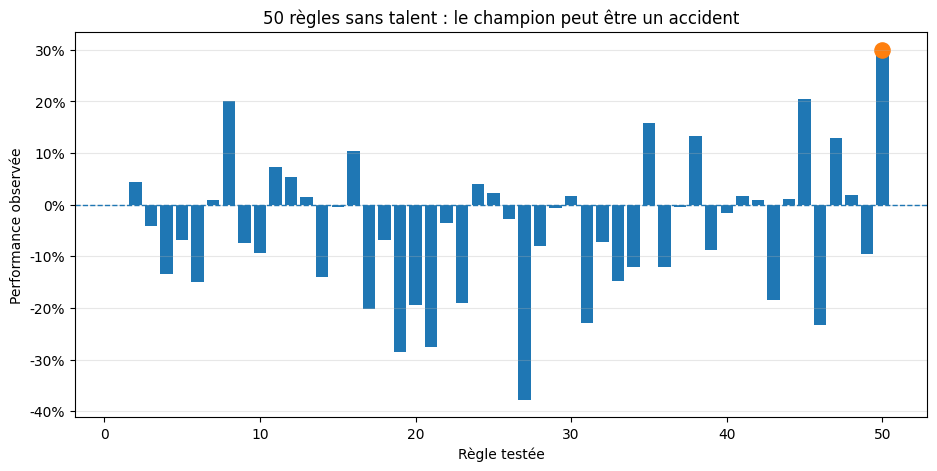

Meilleure règle sélectionnée : règle #50
Pouvoir prédictif réel : 0.0%
Hasard observé : 30.0%
Performance observée : 30.0%


In [4]:
plt.figure(figsize=(11, 5))
plt.bar(df_50["rule_id"], df_50["observed_performance"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.scatter([winner_50["rule_id"]], [winner_50["observed_performance"]], s=120)
plt.title("50 règles sans talent : le champion peut être un accident")
plt.xlabel("Règle testée")
plt.ylabel("Performance observée")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.grid(axis="y", alpha=0.3)
plt.show()

print(f"Meilleure règle sélectionnée : règle #{int(winner_50['rule_id'])}")
print(f"Pouvoir prédictif réel : {winner_50['predictive_power']:.1%}")
print(f"Hasard observé : {winner_50['randomness']:.1%}")
print(f"Performance observée : {winner_50['observed_performance']:.1%}")


## 5. Pourquoi le biais augmente avec le nombre de règles testées

Le biais de minage vient de deux forces combinées :

| Force | Rôle |
|---|---|
| **Variabilité aléatoire** | Chaque règle reçoit une dose de chance ou de malchance |
| **Impératif de sélection** | Le trader choisit la règle avec le meilleur score |

Le hasard seul ne suffit pas à créer le biais.

La sélection seule ne suffit pas non plus.

Le biais naît de leur combinaison :

$$
\text{Data-Mining Bias}
=
\text{Hasard}
\times
\text{Sélection du Maximum}
$$

> Quand tu sélectionnes le maximum, tu ne sélectionnes pas seulement la règle.  
> Tu sélectionnes aussi une quantité extrême de chance.


In [5]:
def max_performance_distribution(n_rules_list, n_experiments=5000, sigma=0.15, true_power=0.0, seed=123):
    rng = np.random.default_rng(seed)
    rows = []
    for n_rules in n_rules_list:
        randomness = rng.normal(loc=0.0, scale=sigma, size=(n_experiments, n_rules))
        observed = true_power + randomness
        max_observed = observed.max(axis=1)
        rows.append({
            "Nombre de règles testées": n_rules,
            "Moyenne du meilleur score": max_observed.mean(),
            "Médiane du meilleur score": np.median(max_observed),
            "95e percentile du meilleur score": np.percentile(max_observed, 95)
        })
    return pd.DataFrame(rows)

n_rules_list = [1, 5, 10, 25, 50, 100, 250, 500, 1000]
summary = max_performance_distribution(n_rules_list)
summary_style = summary.copy()
for col in summary_style.columns[1:]:
    summary_style[col] = summary_style[col].map(lambda x: f"{x:.1%}")
summary_style


,Nombre de règles testées,Moyenne du meilleur score,Médiane du meilleur score,95e percentile du meilleur score
0,1,0.1%,0.1%,24.8%
1,5,17.6%,17.3%,34.8%
2,10,23.0%,22.3%,38.4%
3,25,29.5%,28.9%,42.9%
4,50,33.6%,32.9%,46.3%
5,100,37.7%,37.1%,49.3%
6,250,42.3%,41.6%,52.8%
7,500,45.5%,44.8%,56.2%
8,1000,48.6%,47.8%,58.7%


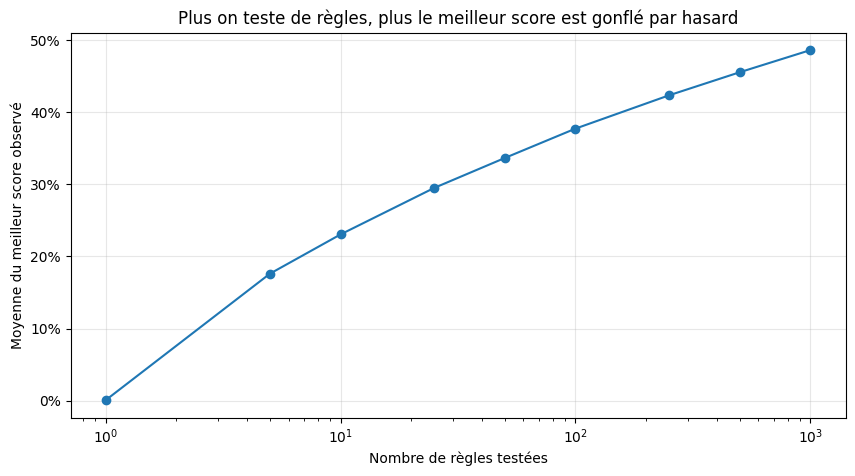

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(summary["Nombre de règles testées"], summary["Moyenne du meilleur score"], marker="o")
plt.xscale("log")
plt.title("Plus on teste de règles, plus le meilleur score est gonflé par hasard")
plt.xlabel("Nombre de règles testées")
plt.ylabel("Moyenne du meilleur score observé")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.grid(alpha=0.3)
plt.show()


## 6. Interprétation EBTA du graphique

Dans la simulation précédente, toutes les règles ont un vrai pouvoir prédictif nul :

$$
P_{pred} = 0
$$

Pourtant, le meilleur score observé augmente fortement avec le nombre de règles testées.

Cela signifie que le champion historique devient de plus en plus suspect à mesure que l’univers de recherche grandit.

> Le meilleur backtest d’un grand univers de règles est rarement une preuve.  
> C’est souvent une alarme statistique.


## 7. Simulation in-sample versus out-of-sample

Pour comprendre la détérioration hors-échantillon, on peut simuler deux périodes :

- **in-sample** : période utilisée pour sélectionner la meilleure règle ;
- **out-of-sample** : nouvelle période où la chance passée ne se répète pas.

Si les règles n’ont aucun vrai talent, la meilleure règle in-sample devrait retomber vers zéro out-of-sample.

C’est exactement le comportement typique du **Fool’s Gold**.


In [7]:
def simulate_in_sample_out_sample(n_rules=200, n_experiments=3000, sigma=0.15, true_power=0.0, seed=999):
    rng = np.random.default_rng(seed)

    in_randomness = rng.normal(0.0, sigma, size=(n_experiments, n_rules))
    out_randomness = rng.normal(0.0, sigma, size=(n_experiments, n_rules))

    in_observed = true_power + in_randomness
    out_observed = true_power + out_randomness

    winners = np.argmax(in_observed, axis=1)
    selected_in = in_observed[np.arange(n_experiments), winners]
    selected_out = out_observed[np.arange(n_experiments), winners]

    return pd.DataFrame({
        "selected_in_sample": selected_in,
        "selected_out_of_sample": selected_out,
        "deterioration": selected_out - selected_in
    })

isoos = simulate_in_sample_out_sample()

pd.DataFrame({
    "Mesure": [
        "Performance moyenne du champion in-sample",
        "Performance moyenne du même champion out-of-sample",
        "Détérioration moyenne"
    ],
    "Valeur": [
        f"{isoos['selected_in_sample'].mean():.1%}",
        f"{isoos['selected_out_of_sample'].mean():.1%}",
        f"{isoos['deterioration'].mean():.1%}"
    ]
})


,Mesure,Valeur
0,Performance moyenne du champion in-sample,41.2%
1,Performance moyenne du même champion out-of-sa...,-0.4%
2,Détérioration moyenne,-41.6%


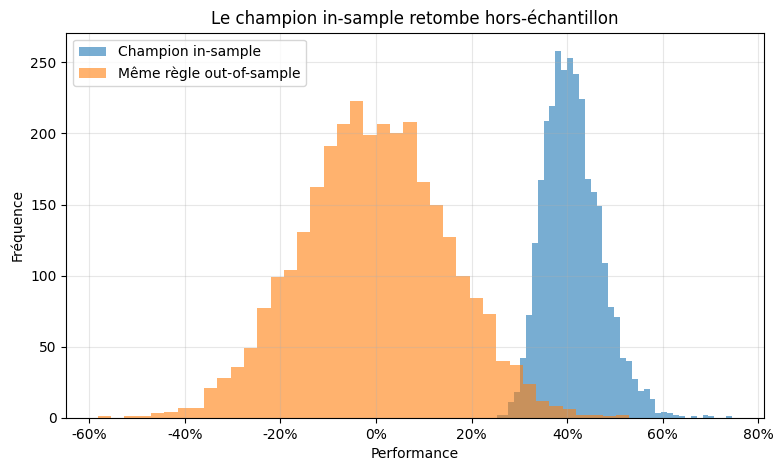

In [8]:
plt.figure(figsize=(9, 5))
plt.hist(isoos["selected_in_sample"], bins=40, alpha=0.6, label="Champion in-sample")
plt.hist(isoos["selected_out_of_sample"], bins=40, alpha=0.6, label="Même règle out-of-sample")
plt.title("Le champion in-sample retombe hors-échantillon")
plt.xlabel("Performance")
plt.ylabel("Fréquence")
plt.gca().xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 8. Lecture trading : pourquoi le champion est dangereux

Le champion d’optimisation est attirant parce qu’il montre la meilleure performance passée.

Mais cette performance est composite :

$$
P_{obs, champion}
=
P_{pred, champion}
+
H_{extrême}
$$

Le terme $H_{extrême}$ est précisément ce qui disparaît le plus facilement hors-échantillon.

Donc, plus le backtest est spectaculaire après une grande recherche, plus il faut se demander :

- combien de règles ont été testées ?
- combien de paramètres ont été optimisés ?
- combien de variantes ont été abandonnées avant de garder le champion ?
- la règle a-t-elle survécu à un vrai test hors-échantillon ?
- la performance reste-t-elle positive après frais, spread et slippage ?

> La question n’est pas : “Quel est le meilleur backtest ?”  
> La vraie question est : “Quelle performance reste quand la chance s’évapore ?”


## 9. Mini-protocole EBTA pour éviter le piège

Voici une checklist pratique :

| Étape | Question |
|---|---|
| 1 | Ai-je testé une seule règle ou un univers de règles ? |
| 2 | Le nombre de variantes testées est-il documenté ? |
| 3 | Le champion est-il trop beau par rapport aux autres règles ? |
| 4 | La performance reste-t-elle solide hors-échantillon ? |
| 5 | Ai-je corrigé le biais de sélection avec une méthode adaptée ? |
| 6 | Ai-je réduit mes attentes futures par rapport au backtest optimisé ? |

Pour une démarche rigoureuse, le trader peut utiliser des approches comme :

- **out-of-sample testing** ;
- **walk-forward analysis** ;
- **Monte Carlo permutation** ;
- **White’s Reality Check** ;
- **Deflated Sharpe Ratio** ;
- **journaling systématique des règles rejetées**.

L’objectif n’est pas de devenir pessimiste.

L’objectif est de séparer le **mérite reproductible** du **bruit chanceux**.


## 10. Eurêka final

> **Performance Observée = Pouvoir Prédictif + Hasard.**

> Le **pouvoir prédictif** est ce que tu peux espérer retrouver.  
> Le **hasard** est ce qui t’a peut-être seulement souri une fois.

> Le data mining devient dangereux quand il transforme un coup de chance historique en conviction stratégique.

Le trader naïf regarde le champion et dit :

> “J’ai trouvé mon edge.”

Le trader EBTA regarde le même champion et demande :

> “Quelle part de ce résultat appartient vraiment au futur ?”


## 11. Expérience interactive : change le nombre de règles

Modifie les paramètres ci-dessous pour observer comment le meilleur score se gonfle quand le nombre de règles testées augmente.

Essaie par exemple :

- `n_rules = 10`
- `n_rules = 100`
- `n_rules = 1000`
- `sigma = 0.10`
- `sigma = 0.25`


Nombre de règles testées : 500
Pouvoir prédictif réel de toutes les règles : 0.0%
Meilleure performance observée : 47.3%
Part due au hasard dans le champion : 47.3%


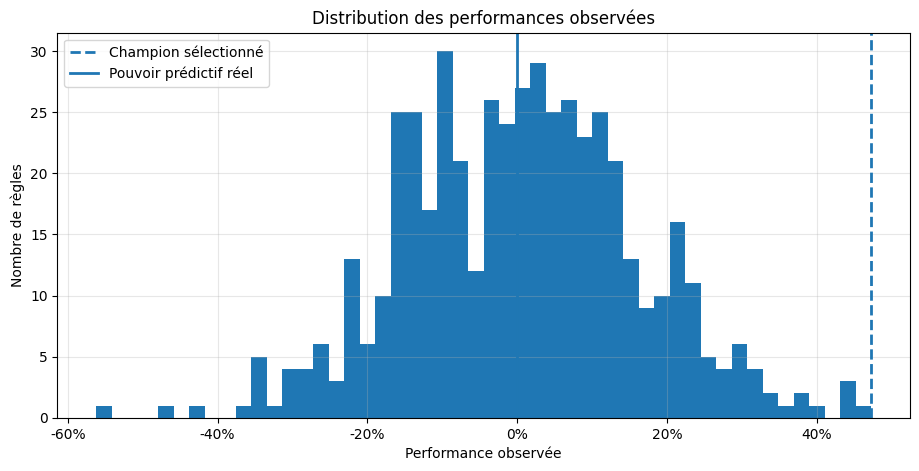

In [9]:
# Paramètres à modifier
n_rules = 500
sigma = 0.15
true_power = 0.00
seed = 2026

df = simulate_rules(n_rules=n_rules, sigma=sigma, true_power=true_power, seed=seed)
winner = df.loc[df["observed_performance"].idxmax()]

print(f"Nombre de règles testées : {n_rules}")
print(f"Pouvoir prédictif réel de toutes les règles : {true_power:.1%}")
print(f"Meilleure performance observée : {winner['observed_performance']:.1%}")
print(f"Part due au hasard dans le champion : {winner['randomness']:.1%}")

plt.figure(figsize=(11, 5))
plt.hist(df["observed_performance"], bins=50)
plt.axvline(winner["observed_performance"], linestyle="--", linewidth=2, label="Champion sélectionné")
plt.axvline(true_power, linestyle="-", linewidth=2, label="Pouvoir prédictif réel")
plt.title("Distribution des performances observées")
plt.xlabel("Performance observée")
plt.ylabel("Nombre de règles")
plt.gca().xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Annexe — Source originale collée

Le texte ci-dessous est la source fournie pour construire ce notebook pédagogique.


### **CH 6 : DATA-MINING BIAS: AN EFFECT WITH TWO CAUSES - TWO COMPONENTS OF OBSERVED PERFORMANCE**

Voici l’analyse technique de la structure de la performance observée et des deux forces qui génèrent mécaniquement le biais de minage de données.

#### **Idées clés :**
*   **Les deux "Vilaains" :** Le biais de minage de données n'est pas dû au seul hasard ; il est le produit conjoint de la **variabilité aléatoire** (hasard) et de l'**impératif de sélection** (choisir le meilleur score).
*   **Décomposition mathématique :** La performance observée en backtest ($P_{obs}$) est la somme de deux composantes indépendantes : le Pouvoir Prédictif ($P_{pred}$) et le Hasard ($H$).
*   **Nature du mérite :** Le pouvoir prédictif est la part de la performance liée à une caractéristique récurrente du marché.
*   **Nature du hasard :** Le hasard (chance ou malchance) est une composante non récurrente qui ne se répétera pas dans le futur pratique.

#### **Référence :**
*Data-Mining Bias: An Effect with Two Causes / Two Components of Observed Performance*, pages 278 à 279.

#### **Citation Directe :**
« The observed performance of a rule can be factored into two components. One component... is attributable to the rule’s true predictive power... The second component... is attributable to randomness. » (Page 279).

#### **Vision Macro :**
L'enjeu est de comprendre la "finitude" de la chance. David Aronson explique que le trader fait souvent une erreur de diagnostic : il attribue l'intégralité de son profit de backtest à la validité de sa règle. En réalité, une grande partie de ce succès n'est qu'une coïncidence temporelle entre les signaux et le bruit du marché. Puisque le hasard, par définition, ne se répète pas, la performance future de la "meilleure" règle chutera inévitablement vers son niveau de mérite réel, souvent bien plus bas, voire nul.

#### **Vision Micro :**
Le mécanisme de distorsion repose sur l'équation fondamentale présentée à la Figure 6.11 :
$$Performance\ Observée = Performance\ Attendue\ \pm\ Hasard$$.

1.  **La Composante de Mérite (Pouvoir Prédictif) :** C'est l'espérance de gain réelle. Si une règle a un talent de +5 % par an, cette part est structurelle et devrait se retrouver hors-échantillon.
2.  **La Composante de Hasard :** Elle agit comme un "bruit" qui peut soit booster (chance), soit plomber (malchance) le résultat du backtest. 
3.  **L'effet de la Sélection :** C'est ici que le biais se cristallise. Dans un univers de 1 000 règles, le data miner sélectionne le profit maximum ($P_{obs}\ max$). Statistiquement, il choisit donc la règle où la composante "Hasard" a été la plus positive.
4.  **L'Inférence Erronée :** Le trader prend ce maximum (dopé à la chance) comme étant le futur attendu, ignorant que la part "Hasard" de l'équation retombera à zéro (sa moyenne long terme) dès le début du trading réel.

#### **Résumé Simplifié :**
Ton profit en backtest, c'est ton Talent + ton Coup de bol. Le talent est durable, mais le coup de bol est unique. Comme le minage de données consiste à chercher la règle qui a le plus gros profit, tu finis mécaniquement par choisir celle qui a eu le plus gros coup de bol de tout ton échantillon. Dès que tu commences à trader, le coup de bol s'arrête, et il ne te reste que le talent, qui est souvent bien décevant par rapport à tes attentes.

#### **Exemples du livre pour mieux comprendre :**
*   **L'équation visuelle (Figure 6.13) :** Aronson illustre que dans les marchés financiers (très bruités), la boîte "Randomness" (Hasard) est bien plus large que la boîte "Predictive Power" (Pouvoir prédictif) dans la composition du profit total.
*   **Le gagnant par accident :** Si 50 règles nulles ($talent = 0$) sont testées, la performance observée sera uniquement due au hasard. Le data miner choisira celle qui a eu +37 % de chance, croyant à tort qu'il a trouvé une règle de talent.

#### **Actions Concrètes :**
*   **Douter systématiquement du "Champion" :** Partez du principe que la performance de votre meilleure règle est largement surestimée par la chance.
*   **Isoler le Pouvoir Prédictif :** Utilisez le White's Reality Check pour déterminer quelle part du profit est statistiquement attribuable au talent plutôt qu'au processus de sélection.
*   **Prévoir une "Prime de Hasard" :** Réduisez vos attentes de profit futur d'au moins 50 % par rapport à vos résultats d'optimisation pour compenser la disparition inévitable de la composante chance.

#### **À retenir absolument :**
*   **Performance Observée = Pouvoir Prédictif + Hasard**.
*   Le Hasard est une composante **non récurrente** (ne se répète pas).
*   Le biais naît de la **Sélection du Maximum** qui favorise la chance extrême.
*   Le profit passé n'est **pas un "talent acquis"**, mais une mesure composite.
*   Ignorer cette décomposition conduit au **"Fool's Gold"**.

J'ai terminé l'analyse des deux composantes de la performance observée selon le protocole EBTA.
